# 01. EDA — 학습셋 / 추론셋 비교

`pl.serial_end`(유료 전환 완결작) 학습셋과 `nv.free`(무료 연재작) 추론셋을 나란히 본다.

핵심 질문 두 개:
1. 타겟이 log1p 변환을 요구하는가?
2. 두 데이터셋의 피처 분포가 얼마나 어긋나 있는가(covariate shift)?

설계 배경은 [로드맵](../docs/04_로드맵.md) "핵심 결정 사항" 참고.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 한글 라벨이 깨지지 않도록 (Windows 기본 폰트)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 4)


In [2]:
from service.model_training import load_dataset, support_band, support_bounds
from service.schema import CATEGORICAL_FEATURE_COLUMNS, NUMERIC_FEATURE_COLUMNS
from service.target_builder import TARGET_COLUMN

labeled = load_dataset("labeled")
free = load_dataset("free")
print(f"학습셋 {len(labeled):,}건 / 추론셋 {len(free):,}건")
labeled.head(3)

학습셋 8,990건 / 추론셋 11,189건


,novel_id,leading_free_episodes,genres,free_views_1_10,retention_1_to_10,retention_1_to_3,likes_1_10,comments_1_10,target_paid_events
0,412618,10,"대체역사,퓨전",237364,0.523158,0.666470,4604,264,536571
1,536180,10,현대판타지,207731,0.724432,0.839386,4629,203,123733
2,510190,10,판타지,480944,0.473379,0.668091,14768,429,535950


## 타겟 분포 — log1p가 필요한 이유

count        8990.0
mean       249554.0
std        639521.0
min             1.0
5%            873.0
25%         14818.0
50%         68048.0
75%        220210.0
95%       1079255.0
max      17120177.0

최대/중앙값 배율: 252배


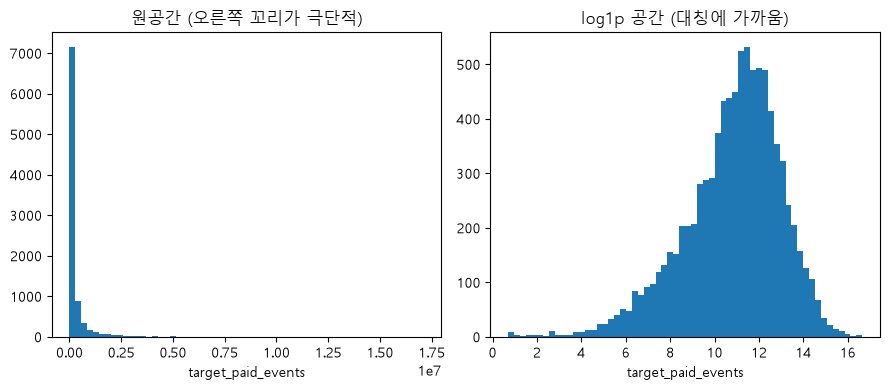

In [3]:
target = labeled[TARGET_COLUMN]
print(target.describe(percentiles=[.05, .25, .5, .75, .95]).round(0).to_string())
print(f"\n최대/중앙값 배율: {target.max() / target.median():,.0f}배")

fig, axes = plt.subplots(1, 2)
axes[0].hist(target, bins=60)
axes[0].set_title("원공간 (오른쪽 꼬리가 극단적)")
axes[1].hist(np.log1p(target), bins=60)
axes[1].set_title("log1p 공간 (대칭에 가까움)")
for ax in axes:
    ax.set_xlabel(TARGET_COLUMN)
plt.tight_layout()

4자릿수 스팬이라 원공간에서 그대로 회귀하면 상위 몇 건이 손실을 지배한다.
학습은 `log1p` 공간에서 하고 `expm1`로 되돌린다(`TransformedTargetRegressor`).

## 피처 분포 비교 — 지지구간 불일치

In [4]:
rows = []
for column in NUMERIC_FEATURE_COLUMNS:
    lo, hi = labeled[column].min(), labeled[column].max()
    rows.append({
        "피처": column,
        "학습 중앙값": labeled[column].median(),
        "추론 중앙값": free[column].median(),
        "학습 5%": labeled[column].quantile(.05),
        "학습 95%": labeled[column].quantile(.95),
        "추론 중 학습범위 내(%)": free[column].between(lo, hi).mean() * 100,
    })
pd.DataFrame(rows).round(3)

,피처,학습 중앙값,추론 중앙값,학습 5%,학습 95%,추론 중 학습범위 내(%)
0,free_views_1_10,185081.500,298.000,1586.000,731535.000,99.437
1,retention_1_to_10,0.513,0.200,0.209,0.691,92.475
2,retention_1_to_3,0.690,0.472,0.392,0.833,98.391
3,likes_1_10,3356.500,5.000,12.000,14055.050,100.000
4,comments_1_10,144.000,1.000,0.000,517.000,100.000


학습셋 5~95% 구간: 1,586 ~ 731,535
희박(하한 미만)    9396
정상           1793

정상 밴드 비율: 16.0%


Text(0.5, 1.0, '밀도는 겹치지 않는다 — 무료작 대부분이 학습셋 하단 바깥')

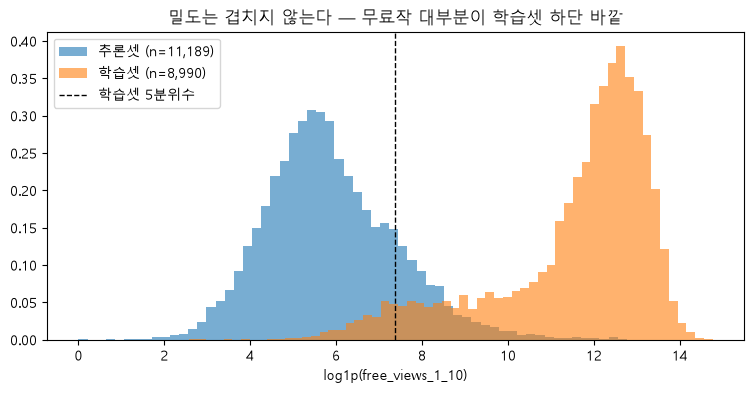

In [5]:
views = NUMERIC_FEATURE_COLUMNS[0]
bounds = support_bounds(labeled[views])
bands = support_band(free[views], bounds)

print(f"학습셋 5~95% 구간: {bounds.lower:,.0f} ~ {bounds.upper:,.0f}")
print(bands.value_counts().to_string())
print(f"\n정상 밴드 비율: {(bands == '정상').mean() * 100:.1f}%")

plt.hist(np.log1p(free[views]), bins=60, alpha=.6, density=True, label=f"추론셋 (n={len(free):,})")
plt.hist(np.log1p(labeled[views]), bins=60, alpha=.6, density=True, label=f"학습셋 (n={len(labeled):,})")
plt.axvline(np.log1p(bounds.lower), color="k", ls="--", lw=1, label="학습셋 5분위수")
plt.xlabel(f"log1p({views})")
plt.legend()
plt.title("밀도는 겹치지 않는다 — 무료작 대부분이 학습셋 하단 바깥")

**범위(min~max)로는 추론셋의 99.4%가 학습셋 안에 들어오지만, 밀도로 보면 84%가 학습셋
5분위수 미만**이다. 범위 기준으로 외삽을 거르면 아무것도 못 거른다 — 분위수 밴드로 갈라야 한다.

예측값은 "유료 전환에 **성공했을 때의** 조건부 기댓값"이므로, 희박 밴드는 대시보드에서
따로 표기한다.

## 장르별 타겟

In [6]:
genre_column = CATEGORICAL_FEATURE_COLUMNS[0]
exploded = (
    labeled.assign(genre=labeled[genre_column].str.split(","))
    .explode("genre")
    .assign(genre=lambda d: d["genre"].str.strip())
)
by_genre = (
    exploded.groupby("genre")[TARGET_COLUMN]
    .agg(["size", "median"])
    .query("size >= 30")
    .sort_values("median", ascending=False)
)
by_genre.round(0)

,size,median
genre,,
대체역사,829,122569.0
스포츠,809,122546.0
드라마,290,116984.0
전쟁·밀리터리,223,112013.0
현대판타지,5004,94674.0
일반소설,64,92578.0
퓨전,3169,73752.0
SF,103,65017.0
게임,327,64837.0


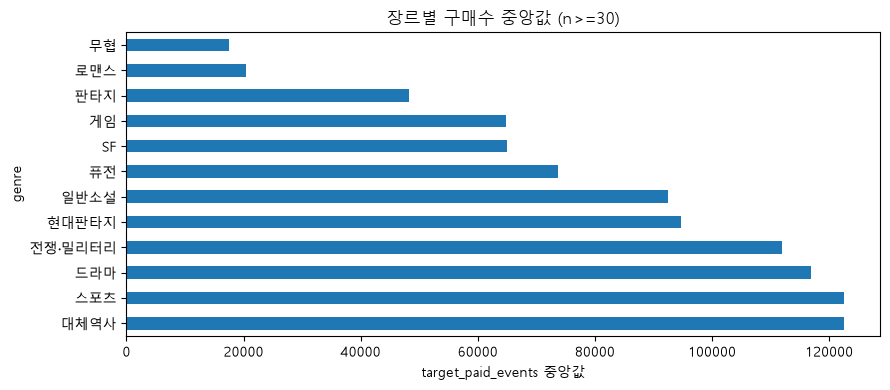

In [7]:
by_genre["median"].plot.barh()
plt.xlabel(f"{TARGET_COLUMN} 중앙값")
plt.title("장르별 구매수 중앙값 (n>=30)")
plt.tight_layout()

장르 간 중앙값 차이가 있어 피처로 쓸 값이 있다. 다만 `genres`는 쉼표로 이어붙인
다중 라벨이라 조합 문자열 그대로 one-hot하면 추론셋 15.5%가 미학습 조합이 된다 —
**토큰 단위 multi-hot**으로 인코딩한다(`service/model_training.build_pipeline`).